# De novo mutational signatures in lung adenocarcinoma (TCGA-LUAD)

### Step 0: Import Statements

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import json
import glob
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pyfaidx import Fasta

### Step 1: Data Processing + Building the SBS-96 Catalogue

We first query the GDC files endpoint to retrieve the list of somatic-mutation (MAF) files for TCGA-LUAD.

In [3]:
files_endpoint = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {
            "op": "in",
            "content": {
                "field": "cases.project.project_id",
                "value": [
                    "TCGA-LUAD"
                ]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "data_type",
                "value": [
                    "Masked Somatic Mutation"
                ]
            }
        },
        {
            "op": "in",
            "content": {
                "field": "access",
                "value": [
                    "open"
                ]
            }
        },
    ]
}

params = {
    "filters": json.dumps(filters),
    "fields": "file_id",
    "format": "JSON",
    "size": "1000"
}

r = requests.get(files_endpoint, params = params)
r.raise_for_status()

data = r.json()["data"]["hits"]

print(f"Found {len(data)} files")

Found 618 files


We next query the data endpoint to download the files themselves.

In [4]:
output_dir = Path("data/luad_mafs")
output_dir.mkdir(parents = True, exist_ok = True)

num_downloaded = 0
data_endpoint = "https://api.gdc.cancer.gov/data"

for item in data:
    file_id = item["file_id"]
    dest_path = output_dir / f"{file_id}.maf.gz"

    if Path(dest_path).exists():
        num_downloaded += 1
        continue

    r = requests.get(f"{data_endpoint}/{file_id}", stream = True)
    r.raise_for_status()

    with dest_path.open("wb") as f:
        for chunk in r.iter_content(chunk_size = 1024 * 1024):
            f.write(chunk)
    num_downloaded += 1

print(f"\n{num_downloaded} files downloaded")


618 files downloaded


We then create a pandas DataFrame out of all the downloaded MAF files. We'll filter the DataFrame to single-base substitutions (SNPs) only, and restricted to the standard chromosomes (1-22, X, and Y).

In [5]:
files = glob.glob("data/luad_mafs/*.maf.gz")
dfs = []

for file in files:
    df = pd.read_csv(file, sep="\t", comment="#", low_memory=False, compression="gzip")
    dfs.append(df)

maf = pd.concat(dfs, ignore_index=True)
print(maf.shape)
print(maf.columns.tolist()[:10])
maf.head()

(194729, 140)
['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Variant_Classification', 'Variant_Type']


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,normal_bam_uuid,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers
0,SCNN1D,6339,BI,GRCh38,chr1,1286845,1286845,+,Missense_Mutation,SNP,...,dc39e473-4ac6-4b42-98f4-4cf9f15256a8,807cc7d2-6e3b-4f2d-9531-0da994eeeada,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2
1,SLC2A5,6518,BI,GRCh38,chr1,9037951,9037951,+,Silent,SNP,...,dc39e473-4ac6-4b42-98f4-4cf9f15256a8,807cc7d2-6e3b-4f2d-9531-0da994eeeada,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2
2,DISP3,57540,BI,GRCh38,chr1,11501970,11501970,+,Silent,SNP,...,dc39e473-4ac6-4b42-98f4-4cf9f15256a8,807cc7d2-6e3b-4f2d-9531-0da994eeeada,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2
3,DISP3,57540,BI,GRCh38,chr1,11536544,11536544,+,Missense_Mutation,SNP,...,dc39e473-4ac6-4b42-98f4-4cf9f15256a8,807cc7d2-6e3b-4f2d-9531-0da994eeeada,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2
4,ZBTB17,7709,BI,GRCh38,chr1,15943125,15943125,+,Silent,SNP,...,dc39e473-4ac6-4b42-98f4-4cf9f15256a8,807cc7d2-6e3b-4f2d-9531-0da994eeeada,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2


We'll inspect the number of SNPs, tumors, and the counts and proportions of each substitution type.

In [6]:
chromosomes = []
for num in np.arange(1, 24):
    chromosomes.append("chr" + str(num))
chromosomes.append(["X", "Y"])

snp = maf[maf["Variant_Type"] == "SNP"].copy()
snp = snp[snp["Chromosome"].isin(chromosomes)].copy()

print(f"{len(snp)} SNPs on the main chromosomes")

178133 SNPs on the main chromosomes


In [7]:
num_tumors = snp["Tumor_Sample_Barcode"].nunique()
print(f"{num_tumors} unique tumors")

print(snp.groupby("Tumor_Sample_Barcode").size().describe())

616 unique tumors
count     616.000000
mean      289.176948
std       309.224979
min         1.000000
25%        77.000000
50%       187.500000
75%       387.750000
max      2323.000000
dtype: float64


In [8]:
snp["Substitutions"] = snp["Reference_Allele"] + ">" + snp["Tumor_Seq_Allele2"]
snp["Substitutions"].value_counts()

Substitutions
C>A    37679
G>T    37305
C>T    22207
G>A    21804
C>G    11985
G>C    11503
T>A     8748
A>T     8377
T>C     6960
A>G     6832
T>G     2386
A>C     2347
Name: count, dtype: int64

In [9]:
snp["Substitutions"].value_counts(normalize=True)

Substitutions
C>A    0.211522
G>T    0.209422
C>T    0.124665
G>A    0.122403
C>G    0.067281
G>C    0.064575
T>A    0.049109
A>T    0.047027
T>C    0.039072
A>G    0.038353
T>G    0.013394
A>C    0.013176
Name: proportion, dtype: float64

We can see that the majority of the substitutions are C>A, followed by G>T (which is the reverse complement of C>A).

To build the catalogue, we use the pyrimidine convention, where every substitution is expressed with a pyrimidine (C or T) as the mutated base, taking the reverse complement when the reference base is a purine (A or G). This avoids double counting; a C>T on one strand is a G>A on the other, so collapsing to the pyrimidine gives six substitution types (C>A, C>G, C>T, T>A, T>C, T>G) rather than twelve.
Each mutation is classified by its trinucleotide context — the base immediately 5', then the mutated base, and then the base immediately 3'. An example would be A[C>G]G. From the 6 substitution types, 4 possible 5' bases, and 4 possible 3' bases come the 96 channels of the SBS-96 catalogue.

In [10]:
genome = Fasta("data/raw/hg38.fa")

complements = {"A":"T", "C":"G", "G":"C", "T":"A"}
pyrimidines = {"C", "T"}
bases = {"A", "C", "G", "T"}

def reverse_complement(seq):
    rev = reversed(seq)
    comp = ""
    for c in rev:
        comp += complements[c]
    return comp

def sbs96_channel(chromosome, position, ref_allele, alt_allele):
    try:
        tri = str(genome[chromosome][position - 2 : position + 1]).upper()
    except Exception:
        return None

    if len(tri) != 3 or "N" in tri:
        return None
    if tri[1] != ref_allele:
        return None
    if alt_allele not in bases:
        return None
    if ref_allele == alt_allele:
        return None

    if ref_allele not in pyrimidines:
        ref_allele = complements[ref_allele]
        alt_allele = complements[alt_allele]
        tri = reverse_complement(tri)

    sbs96_label = f"{tri[0]}[{ref_allele}>{alt_allele}]{tri[2]}"
    return sbs96_label

In [11]:
substitutions = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
bases = ["A", "C", "G", "T"]
channels = []
for s in substitutions:
    for b1 in bases:
        for b2 in bases:
            channels.append(f"{b1}[{s}]{b2}")
assert len(channels) == 96

In [12]:
row = snp.iloc[0]
print(row["Chromosome"], row["Start_Position"], row["Reference_Allele"], row["Tumor_Seq_Allele2"])
print(sbs96_channel(row["Chromosome"], row["Start_Position"], row["Reference_Allele"], row["Tumor_Seq_Allele2"]))

chr1 1286845 A T
G[T>A]T


In [13]:
snp["Channel"] = [sbs96_channel(c, p, r, a) for c, p, r, a in zip(snp["Chromosome"], snp["Start_Position"], snp["Reference_Allele"], snp["Tumor_Seq_Allele2"])]

In [14]:
dropped = snp["Channel"].isna().sum()
print(f"Dropped {dropped} SNPs out of {len(snp)}; {dropped/len(snp)*100}% dropped")
snp = snp.dropna(subset=["Channel"])

Dropped 0 SNPs out of 178133; 0.0% dropped


In [15]:
matrix = (snp.groupby(["Channel", "Tumor_Sample_Barcode"]).size()
          .unstack(fill_value=0)
          .reindex(channels, fill_value=0))
print("catalogue:", matrix.shape)
matrix.head()

catalogue: (96, 616)


Tumor_Sample_Barcode,TCGA-05-4244-01A-01D-1105-08,TCGA-05-4249-01A-01D-1105-08,TCGA-05-4250-01A-01D-1105-08,TCGA-05-4382-01A-01D-1931-08,TCGA-05-4384-01A-01D-1753-08,TCGA-05-4389-01A-01D-1265-08,TCGA-05-4390-01A-02D-1753-08,TCGA-05-4395-01A-01D-1265-08,TCGA-05-4396-01A-21D-1855-08,TCGA-05-4397-01A-01D-1265-08,...,TCGA-NJ-A4YG-01A-22D-A25L-08,TCGA-NJ-A4YI-01A-11D-A25L-08,TCGA-NJ-A4YP-01A-11D-A25L-08,TCGA-NJ-A4YQ-01A-11D-A25L-08,TCGA-NJ-A55A-01A-11D-A25L-08,TCGA-NJ-A55O-01A-11D-A25L-08,TCGA-NJ-A55R-01A-11D-A25L-08,TCGA-NJ-A7XG-01A-12D-A397-08,TCGA-O1-A52J-01A-11D-A25L-08,TCGA-S2-AA1A-01A-12D-A397-08
Channel,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,5,8,6,48,5,1,16,9,6,13,...,0,11,3,25,1,2,3,0,3,4
A[C>A]C,4,8,1,60,1,2,8,5,4,24,...,4,13,6,29,6,3,6,1,4,3
A[C>A]G,4,4,9,23,3,0,11,3,3,15,...,2,9,6,23,0,5,3,0,3,2
A[C>A]T,2,6,11,37,1,2,9,2,7,12,...,1,7,3,18,0,0,9,0,2,2
C[C>A]A,12,11,12,111,5,6,32,10,8,42,...,5,37,8,74,4,7,9,1,10,13


In [16]:
matrix.to_csv("data/processed/sbs96_matrix.csv")

In [17]:
keep = matrix.columns[matrix.sum() >= 50]
matrix = matrix[keep]
print(f"{matrix.shape[1]} tumors retained after filter")

508 tumors retained after filter


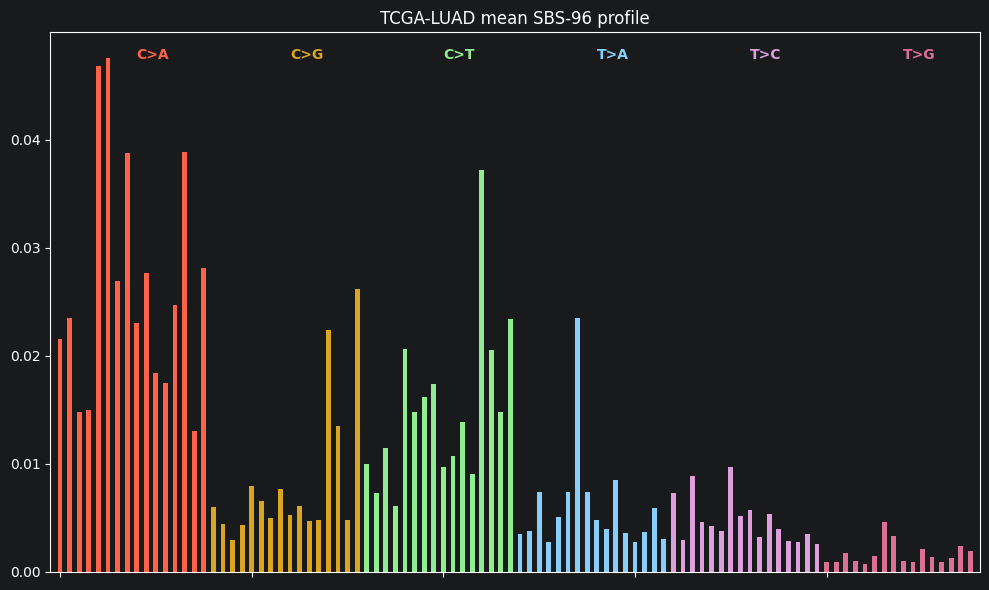

In [18]:
sbs_colors = {"C>A": "tomato", "C>G": "goldenrod", "C>T": "lightgreen", "T>A": "lightskyblue", "T>C": "plum", "T>G": "palevioletred"}

def plot_sbs96(vector, axis, title=""):
    if not isinstance(vector, pd.Series):
        vector = pd.Series(vector, index=channels)
    else:
        vector = vector.reindex(channels, fill_value=0)

    colors = []
    for channel in channels:
        mutation = channel[2:5]
        colors.append(sbs_colors[mutation])

    axis.bar(range(96), vector.values, color=colors, width=0.5)
    axis.set_xlim(-1, 96)
    axis.set_xticklabels([])
    axis.set_title(title)

    for i, s in enumerate(substitutions):
        axis.text(i*16 + 8, axis.get_ylim()[1] * 0.95, s, color=sbs_colors[s], weight="bold")

mean_profile = matrix.sum(axis=1)
mean_profile = mean_profile / mean_profile.sum()

fig, ax = plt.subplots(figsize=(10, 6))
plot_sbs96(mean_profile, ax, "TCGA-LUAD mean SBS-96 profile")
plt.tight_layout()
plt.savefig("results/figures/luad_mean_profile.png", dpi=150)
plt.show()

### Step 2: NMF

We use NMF from scikit-learn. NMF decomposes the input matrix V (tumors x 96 mutation types) into two smaller matrices, W and H, such that V ≈ W x H. W (tumors x signatures) gives each tumor's signature composition — e.g. Tumor 1 is 70% Signature 1, 20% Signature 2, 10% Signature 3. H (signatures x 96 mutation types) gives the signatures htemselves: each row is the 96-channel pattern a signle mutational process would produce if it acted alone. We use non-negative factorization specifically because mutation counts can't be negative, so negative matrix values wouldn't make sense.
For a given number of signatures k, NMF searches for W and H that best reconstruct V. Choosing k is the crux of it (which we'll look more into in Step 3), and we judge it with two quantities.
Reconstruction error measures how far W x H is from V. It almost always decreases as k increases. It's like estimating a picture using only two colors, versus using twenty colors — the more colors, the better the estimation will be. The second quantity is stability, which measureshow reproducible the signatures are across random restarts. If k always yields the same signatures, stability is high. If it yields different signatures each run, it's too low. High error with high stability means the model is too simple (too few signatures); low error but low stability means the model is too complicated. The rght k is where the error has leveled off but the stability is still high.
Biologically, a larger k splits one real process into multiple pieces; too small a k merges distinct processes into one.

In [19]:
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

In [20]:
V = matrix.T.values.astype(float)
V.shape

(508, 96)

We set the beta_loss parameter of the NMF function to "kullback-leibler", which is the standard for count data / Poisson-like distributions, and max_iter is 3000.

In [21]:
def run_nmf(V, k, seed):
    model = NMF(n_components=k, init="random", random_state=seed, max_iter=3000, solver="mu", beta_loss="kullback-leibler")
    W = model.fit_transform(V)
    H = model.components_
    return W, H, model.reconstruction_err_

### Step 3 - Rank Selection

We test each k from 2 to 20, running 25 restarts per k and recording mean reconstruction error and stability.

In [22]:
error_per_k = {}
stability_per_k = {}

num_attempts = 25
k_range = np.arange(2, 20)

for k in k_range:
    errors = []
    H_matrices = []
    # First, we track the errors and the H matrices.
    for s in range(num_attempts):
        W, H, error = run_nmf(V, k, s)
        errors.append(error)
        normalized = H / H.sum(axis=1, keepdims=True)
        H_matrices.append(normalized)

    similarities = []
    # Next, we track the stability.
    for i in range(num_attempts):
        for j in range(i+1, num_attempts):
            similarities.append(cosine_similarity(H_matrices[i], H_matrices[j]).max(axis=1).mean())
        error_per_k[k] = np.mean(errors)
        stability_per_k[k] = np.mean(similarities)
    print(f"k = {k}: error = {error_per_k[k]: .3f}, stability = {stability_per_k[k]: .3f}")

k = 2: error =  245.087, stability =  1.000
k = 3: error =  231.728, stability =  0.996
k = 4: error =  227.968, stability =  0.967
k = 5: error =  225.214, stability =  0.939
k = 6: error =  221.894, stability =  0.928
k = 7: error =  219.414, stability =  0.903
k = 8: error =  217.002, stability =  0.898
k = 9: error =  214.979, stability =  0.882
k = 10: error =  212.838, stability =  0.873
k = 11: error =  210.965, stability =  0.852
k = 12: error =  209.129, stability =  0.840
k = 13: error =  207.263, stability =  0.825
k = 14: error =  205.490, stability =  0.815
k = 15: error =  203.744, stability =  0.806
k = 16: error =  202.199, stability =  0.790
k = 17: error =  200.490, stability =  0.780
k = 18: error =  198.842, stability =  0.775
k = 19: error =  197.193, stability =  0.769


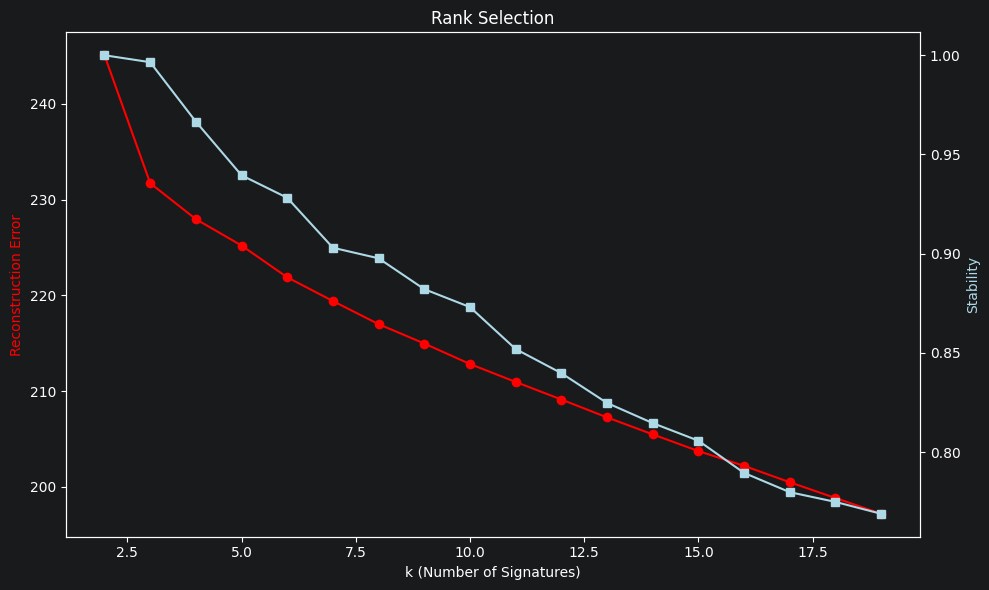

In [23]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(list(k_range), [error_per_k[k] for k in k_range], "o-", color="red")
ax1.set_ylabel("Reconstruction Error", color="red")
ax1.set_xlabel("k (Number of Signatures)")

ax2 = ax1.twinx()
ax2.plot(list(k_range), [stability_per_k[k] for k in k_range], "s-", color="lightblue")
ax2.set_ylabel("Stability", color="lightblue")

plt.title("Rank Selection")
plt.tight_layout()

plt.savefig("results/figures/rank_selection.png", dpi=150)
plt.show()

Plotting both reconstruction and stability against k, we see that the suitable range is between k=2 and k=6. Error's steep decline flattens in that range and stability remains above 0.90. We next plot the extracted signatures per k.

The find_min_error function below runs NMF with the same V and K value for a range of seeds between 1 and 20, and returns the results from the run with the smallest error.

In [24]:
def find_min_error(V, K):
    W, H, min_error = run_nmf(V, K, 1)
    for s in range(2, 20):
        curr_W, curr_H, curr_error = run_nmf(V, K, s)
        if curr_error < min_error:
            min_error = curr_error
            W = curr_W
            H = curr_H
    return W, H, min_error

In [25]:
def graph_signatures(V, K):
    W, H, min_error = find_min_error(V, K)

    indices = []
    for i in range(K):
        indices.append(f"Sig{i+1}")

    signatures = pd.DataFrame(H, columns=channels, index=indices)
    signatures = signatures.T
    signatures = signatures / signatures.sum()

    fig, axes = plt.subplots(K, 1, figsize=(20, 18))
    for i, name in enumerate(signatures.columns):
        plot_sbs96(signatures[name], axes[i])

    fig.suptitle(f"Signatures: Rank {K}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
    plt.savefig(f"results/figures/signatures_rank{K}.png", dpi=150)
    plt.show()

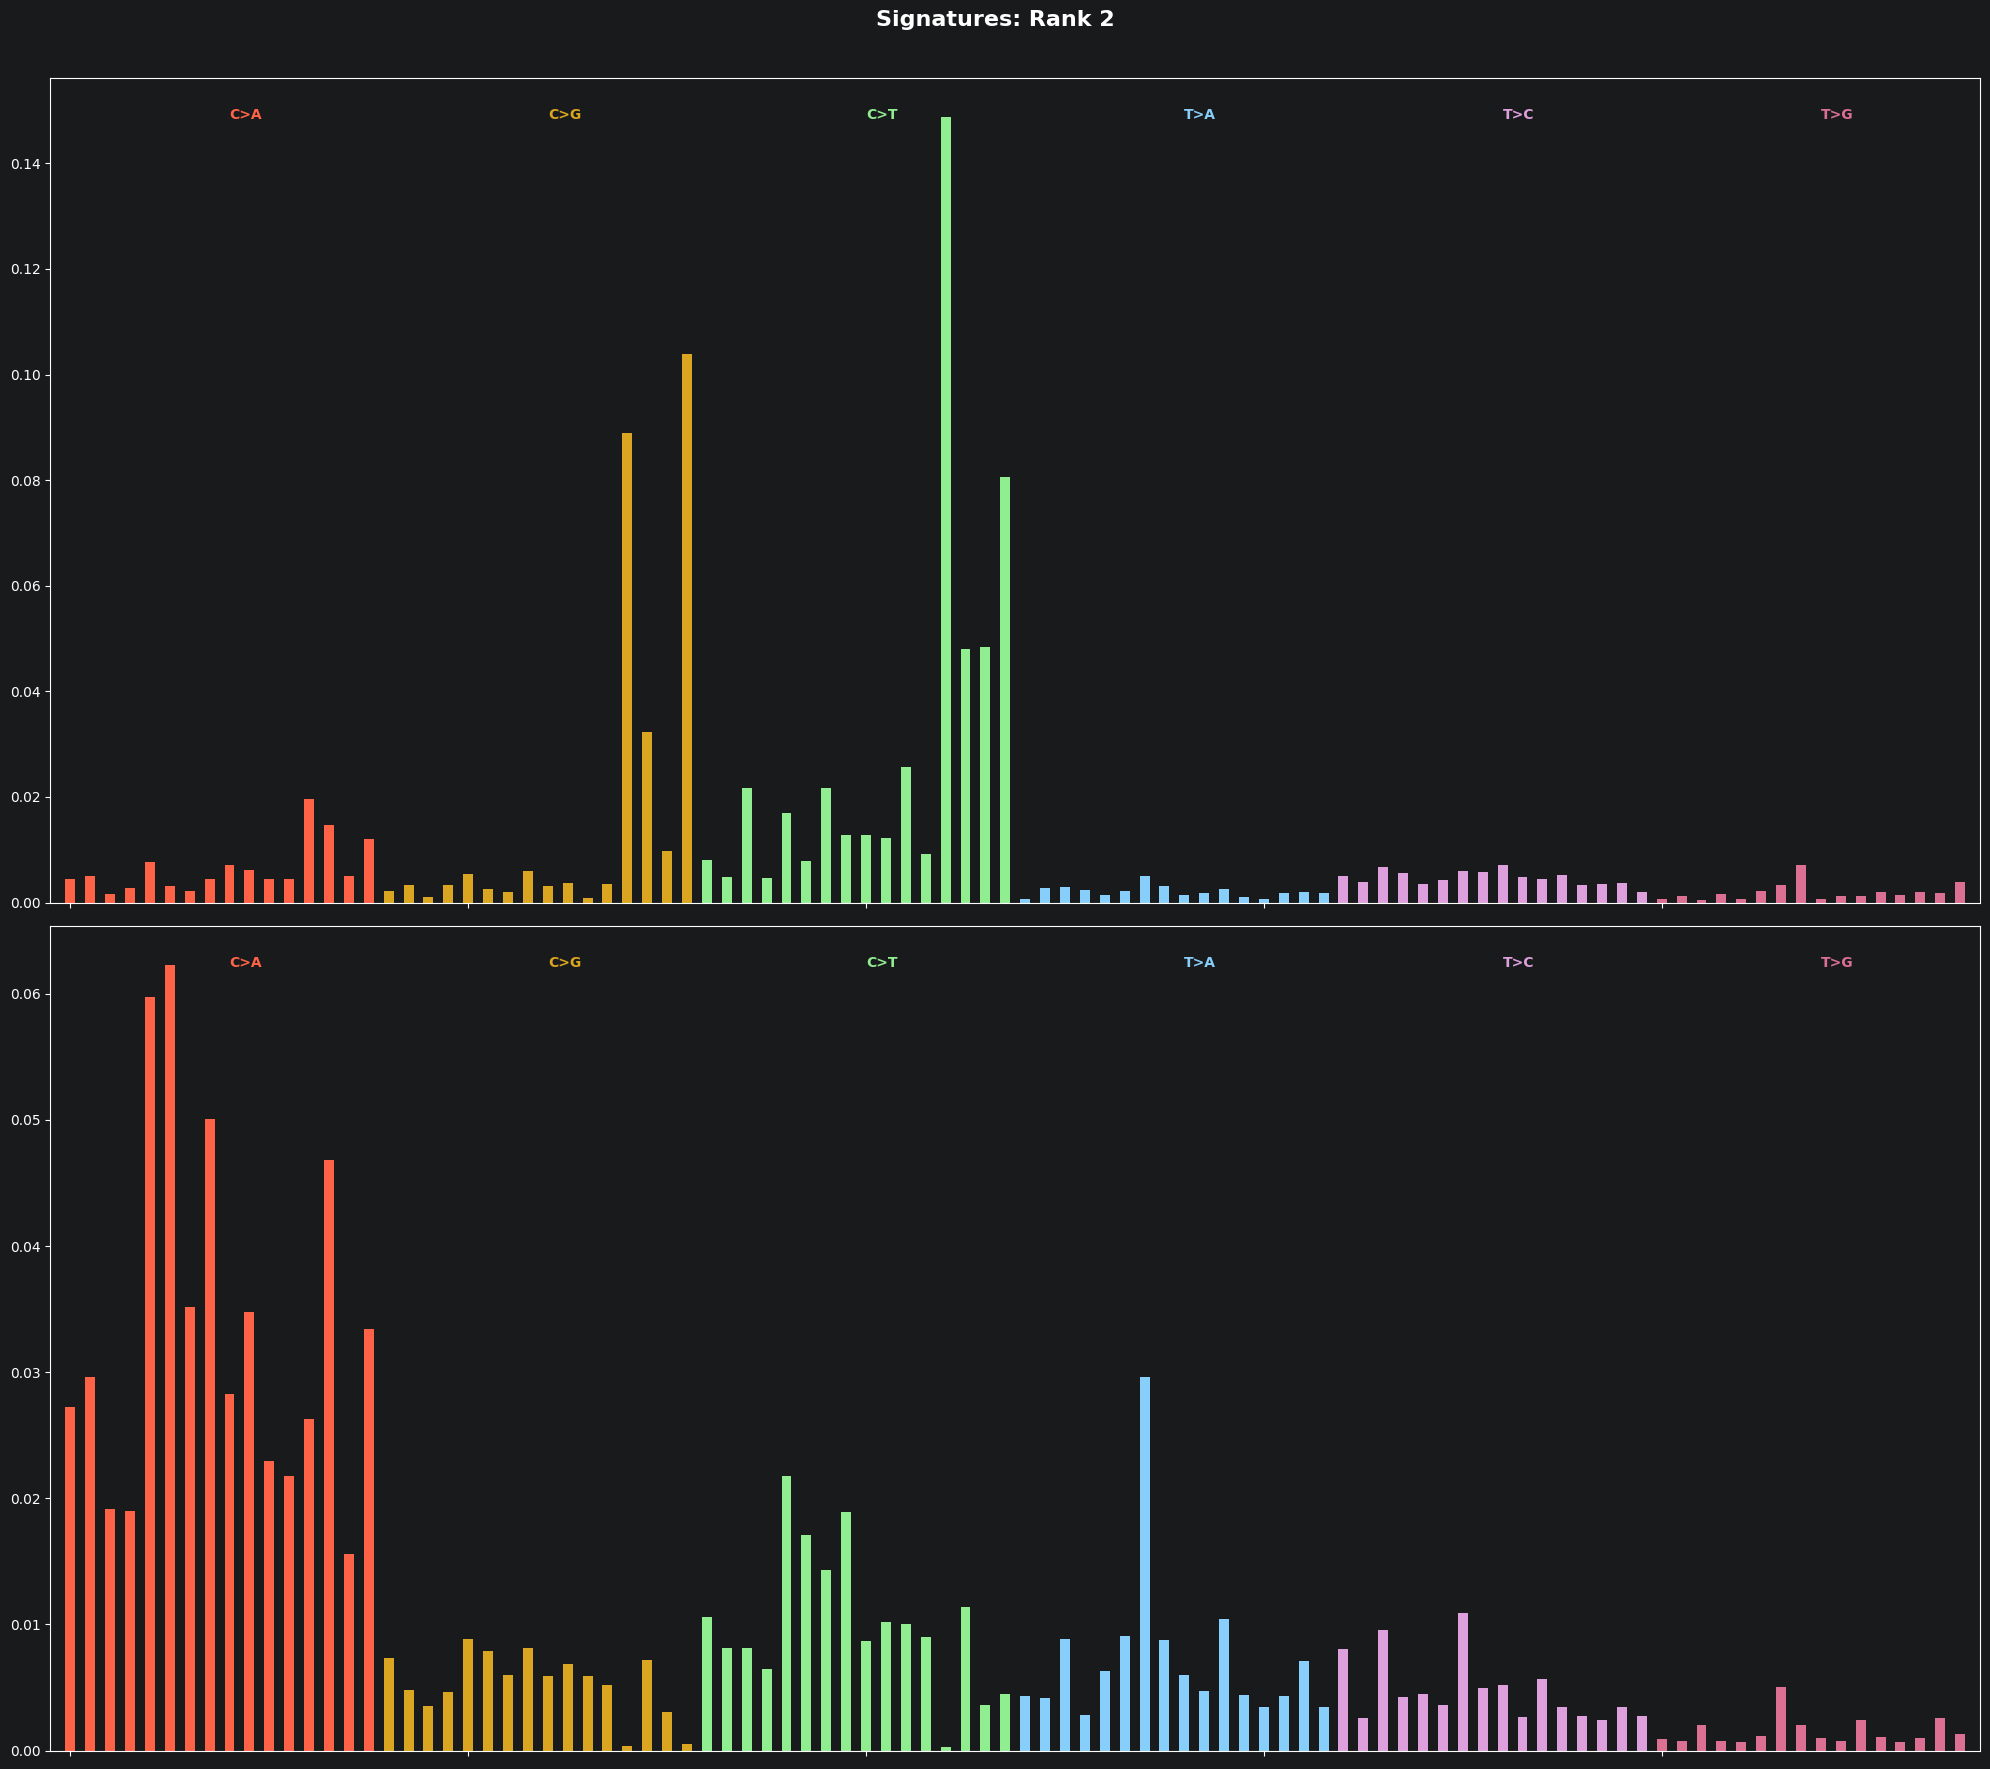

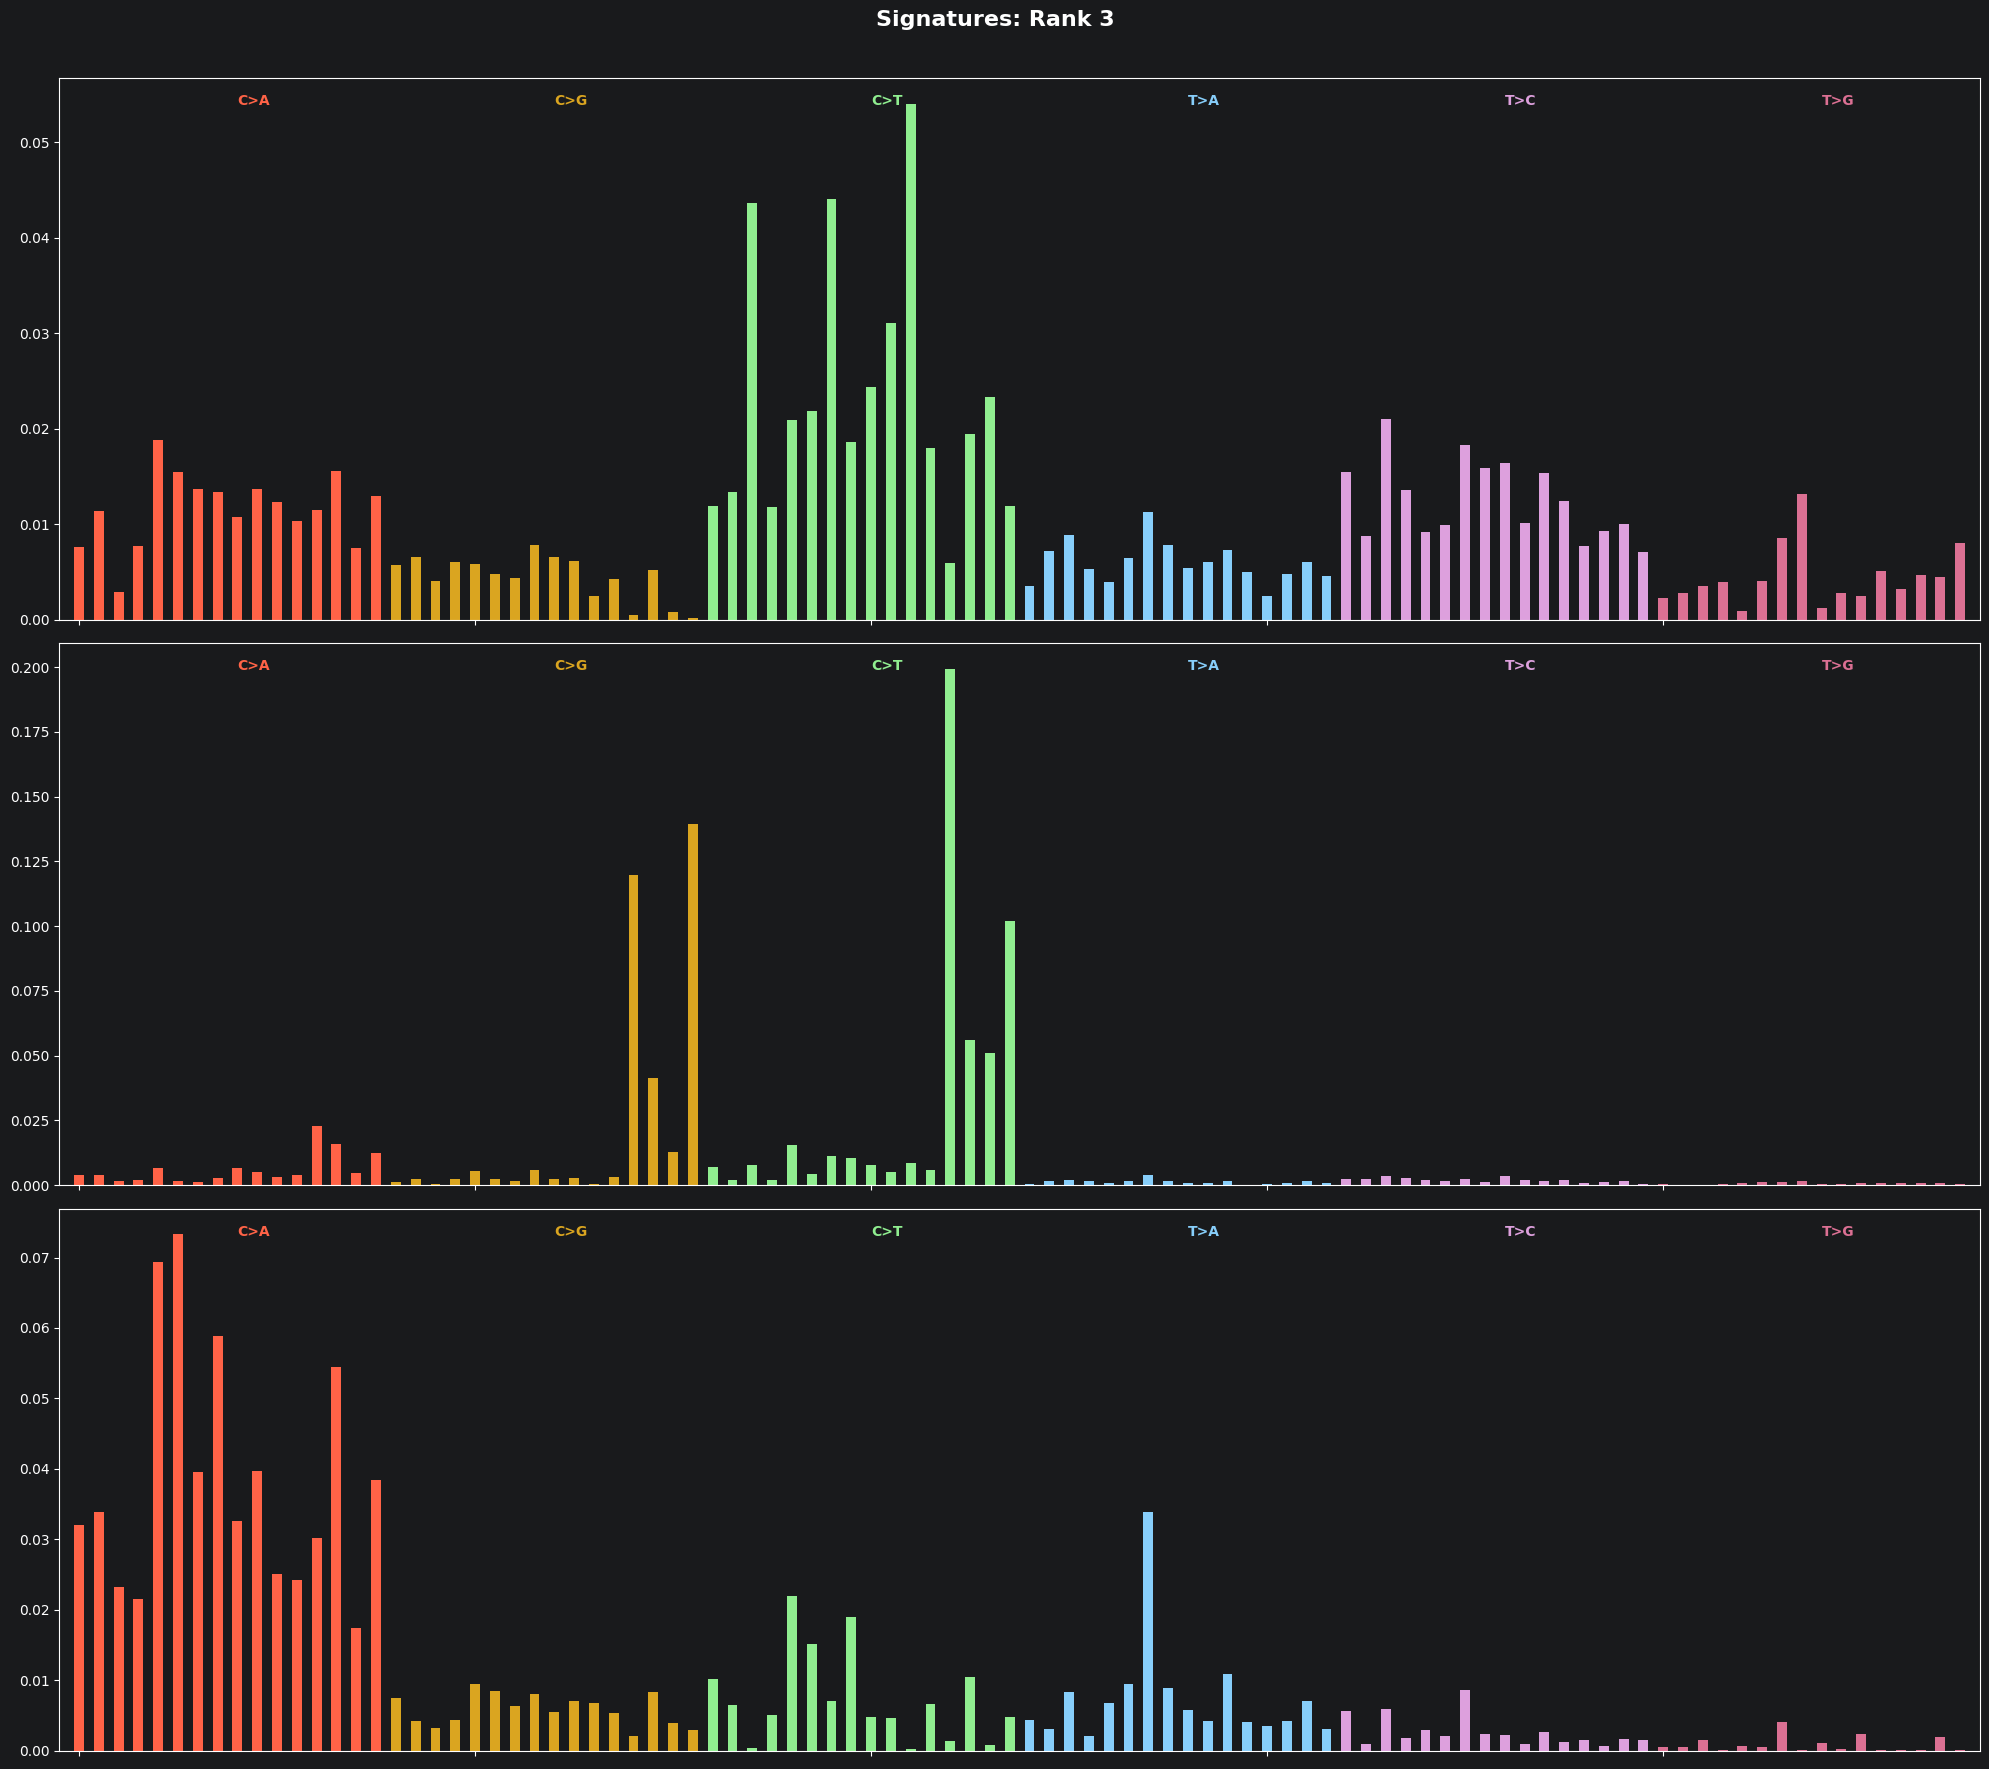

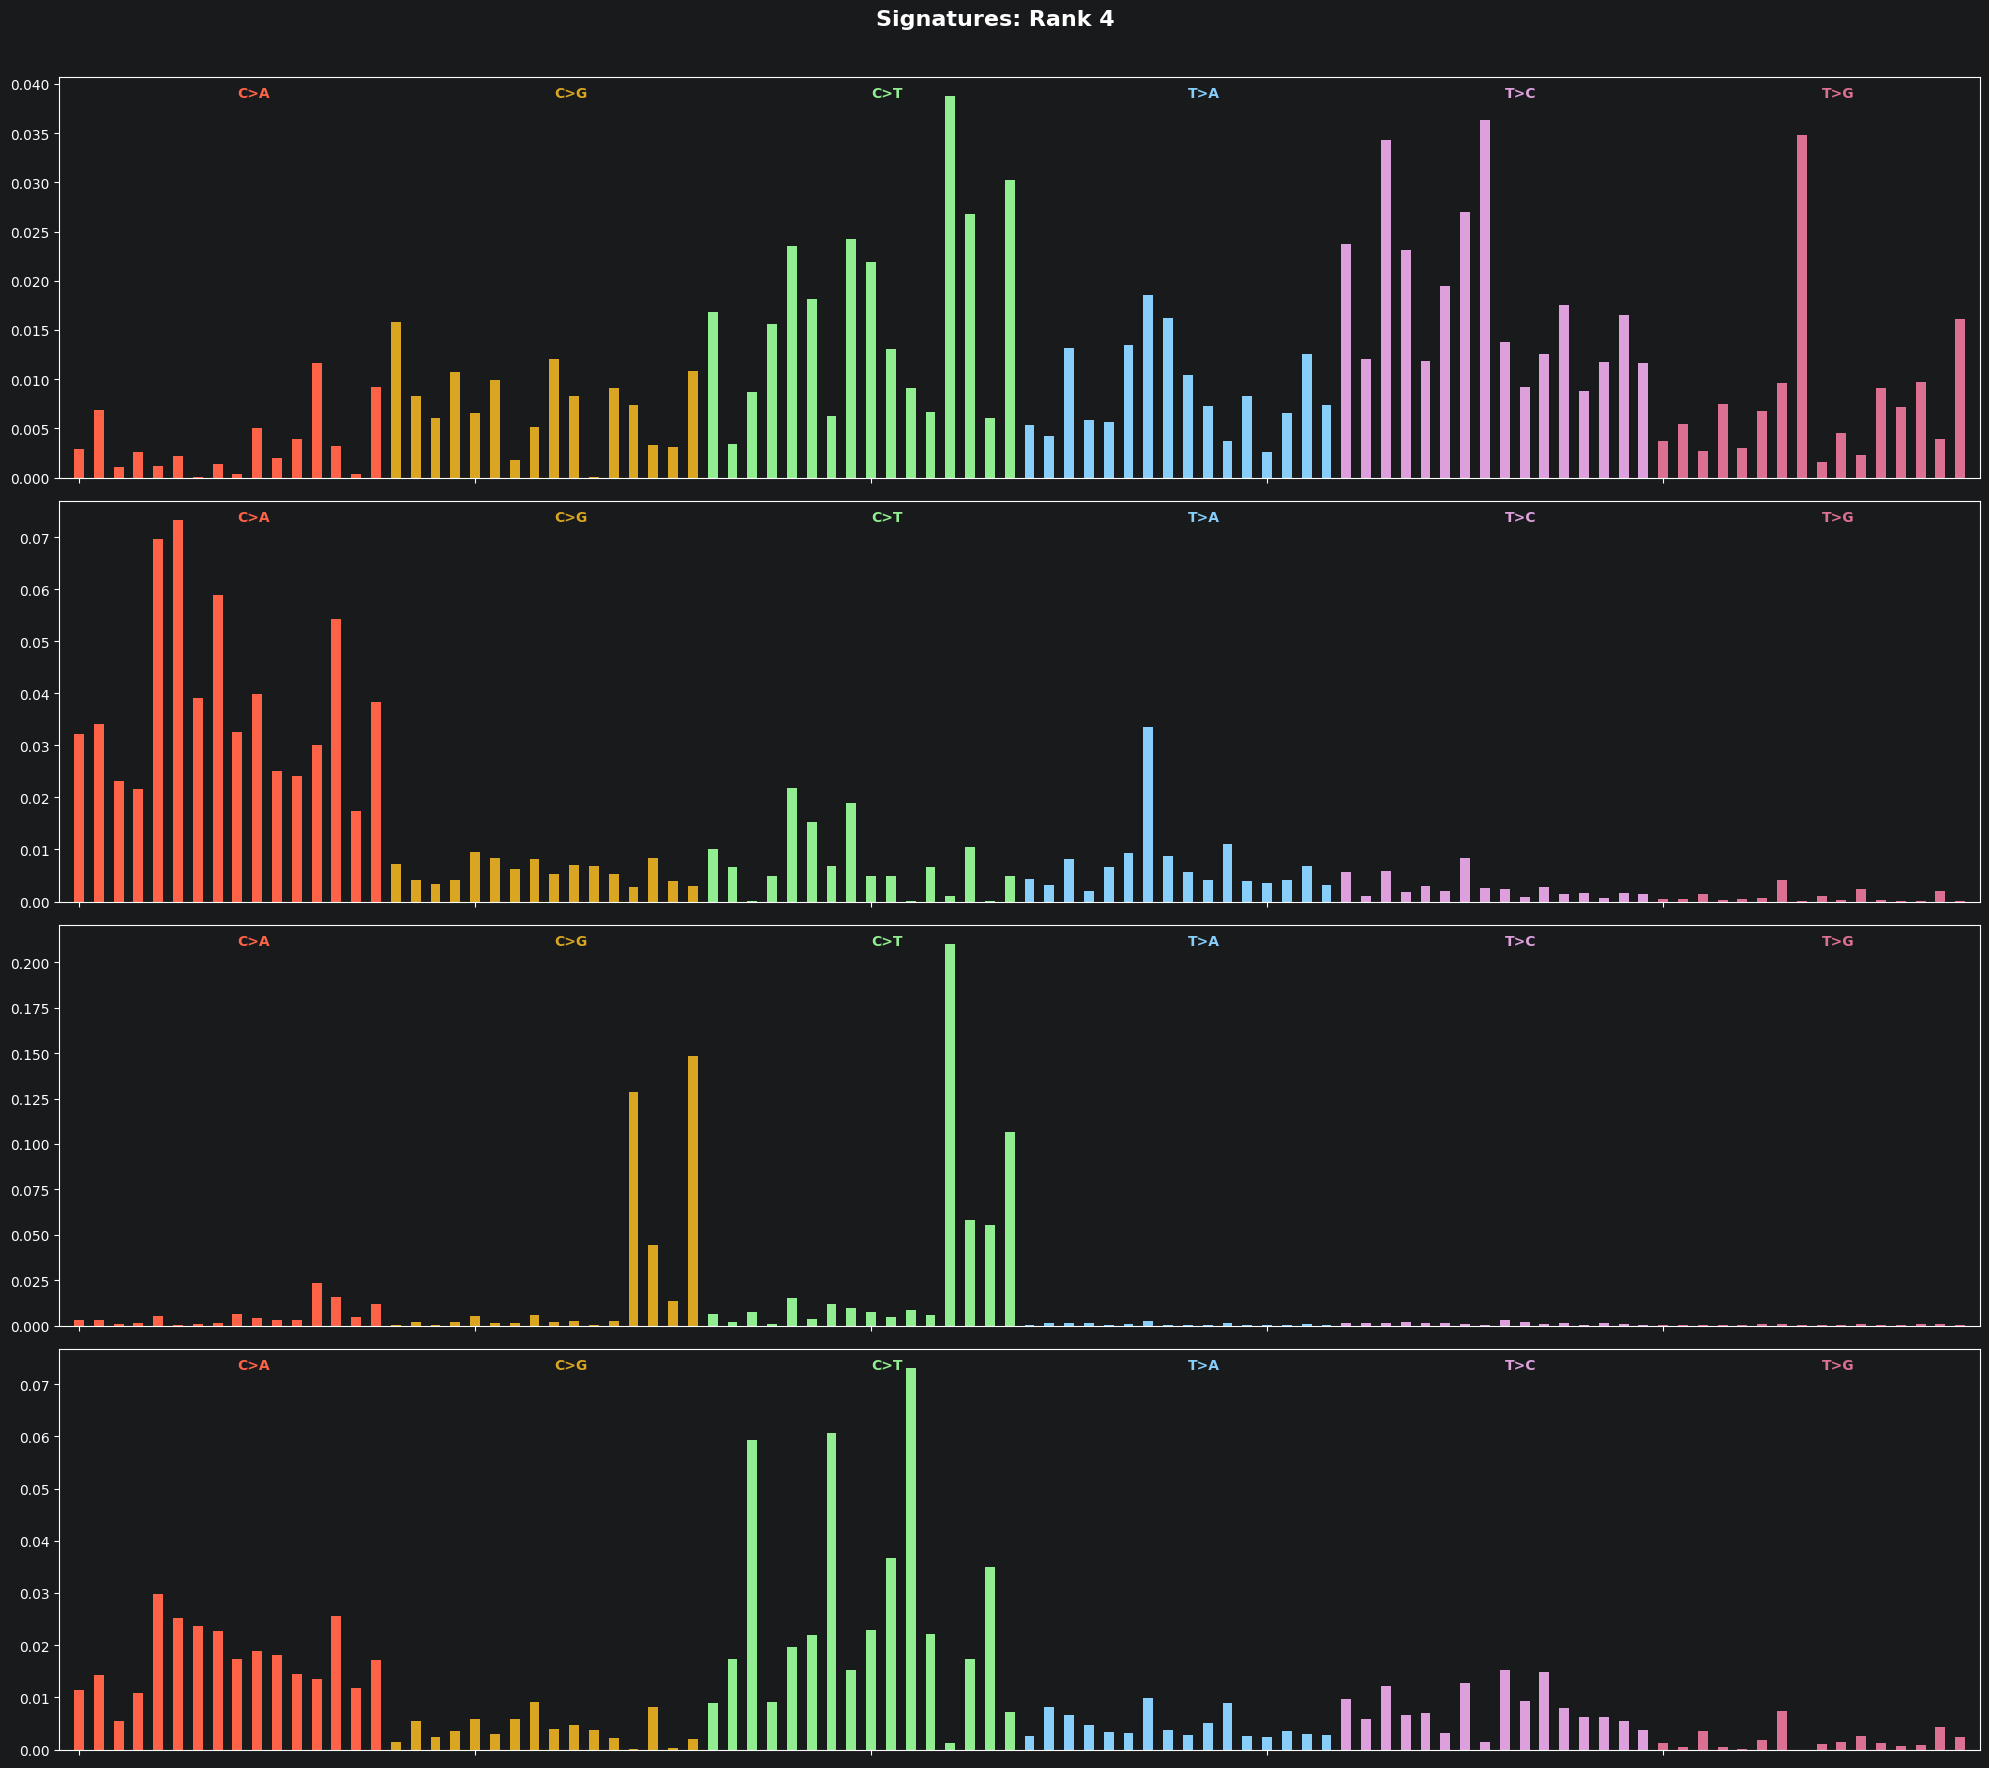

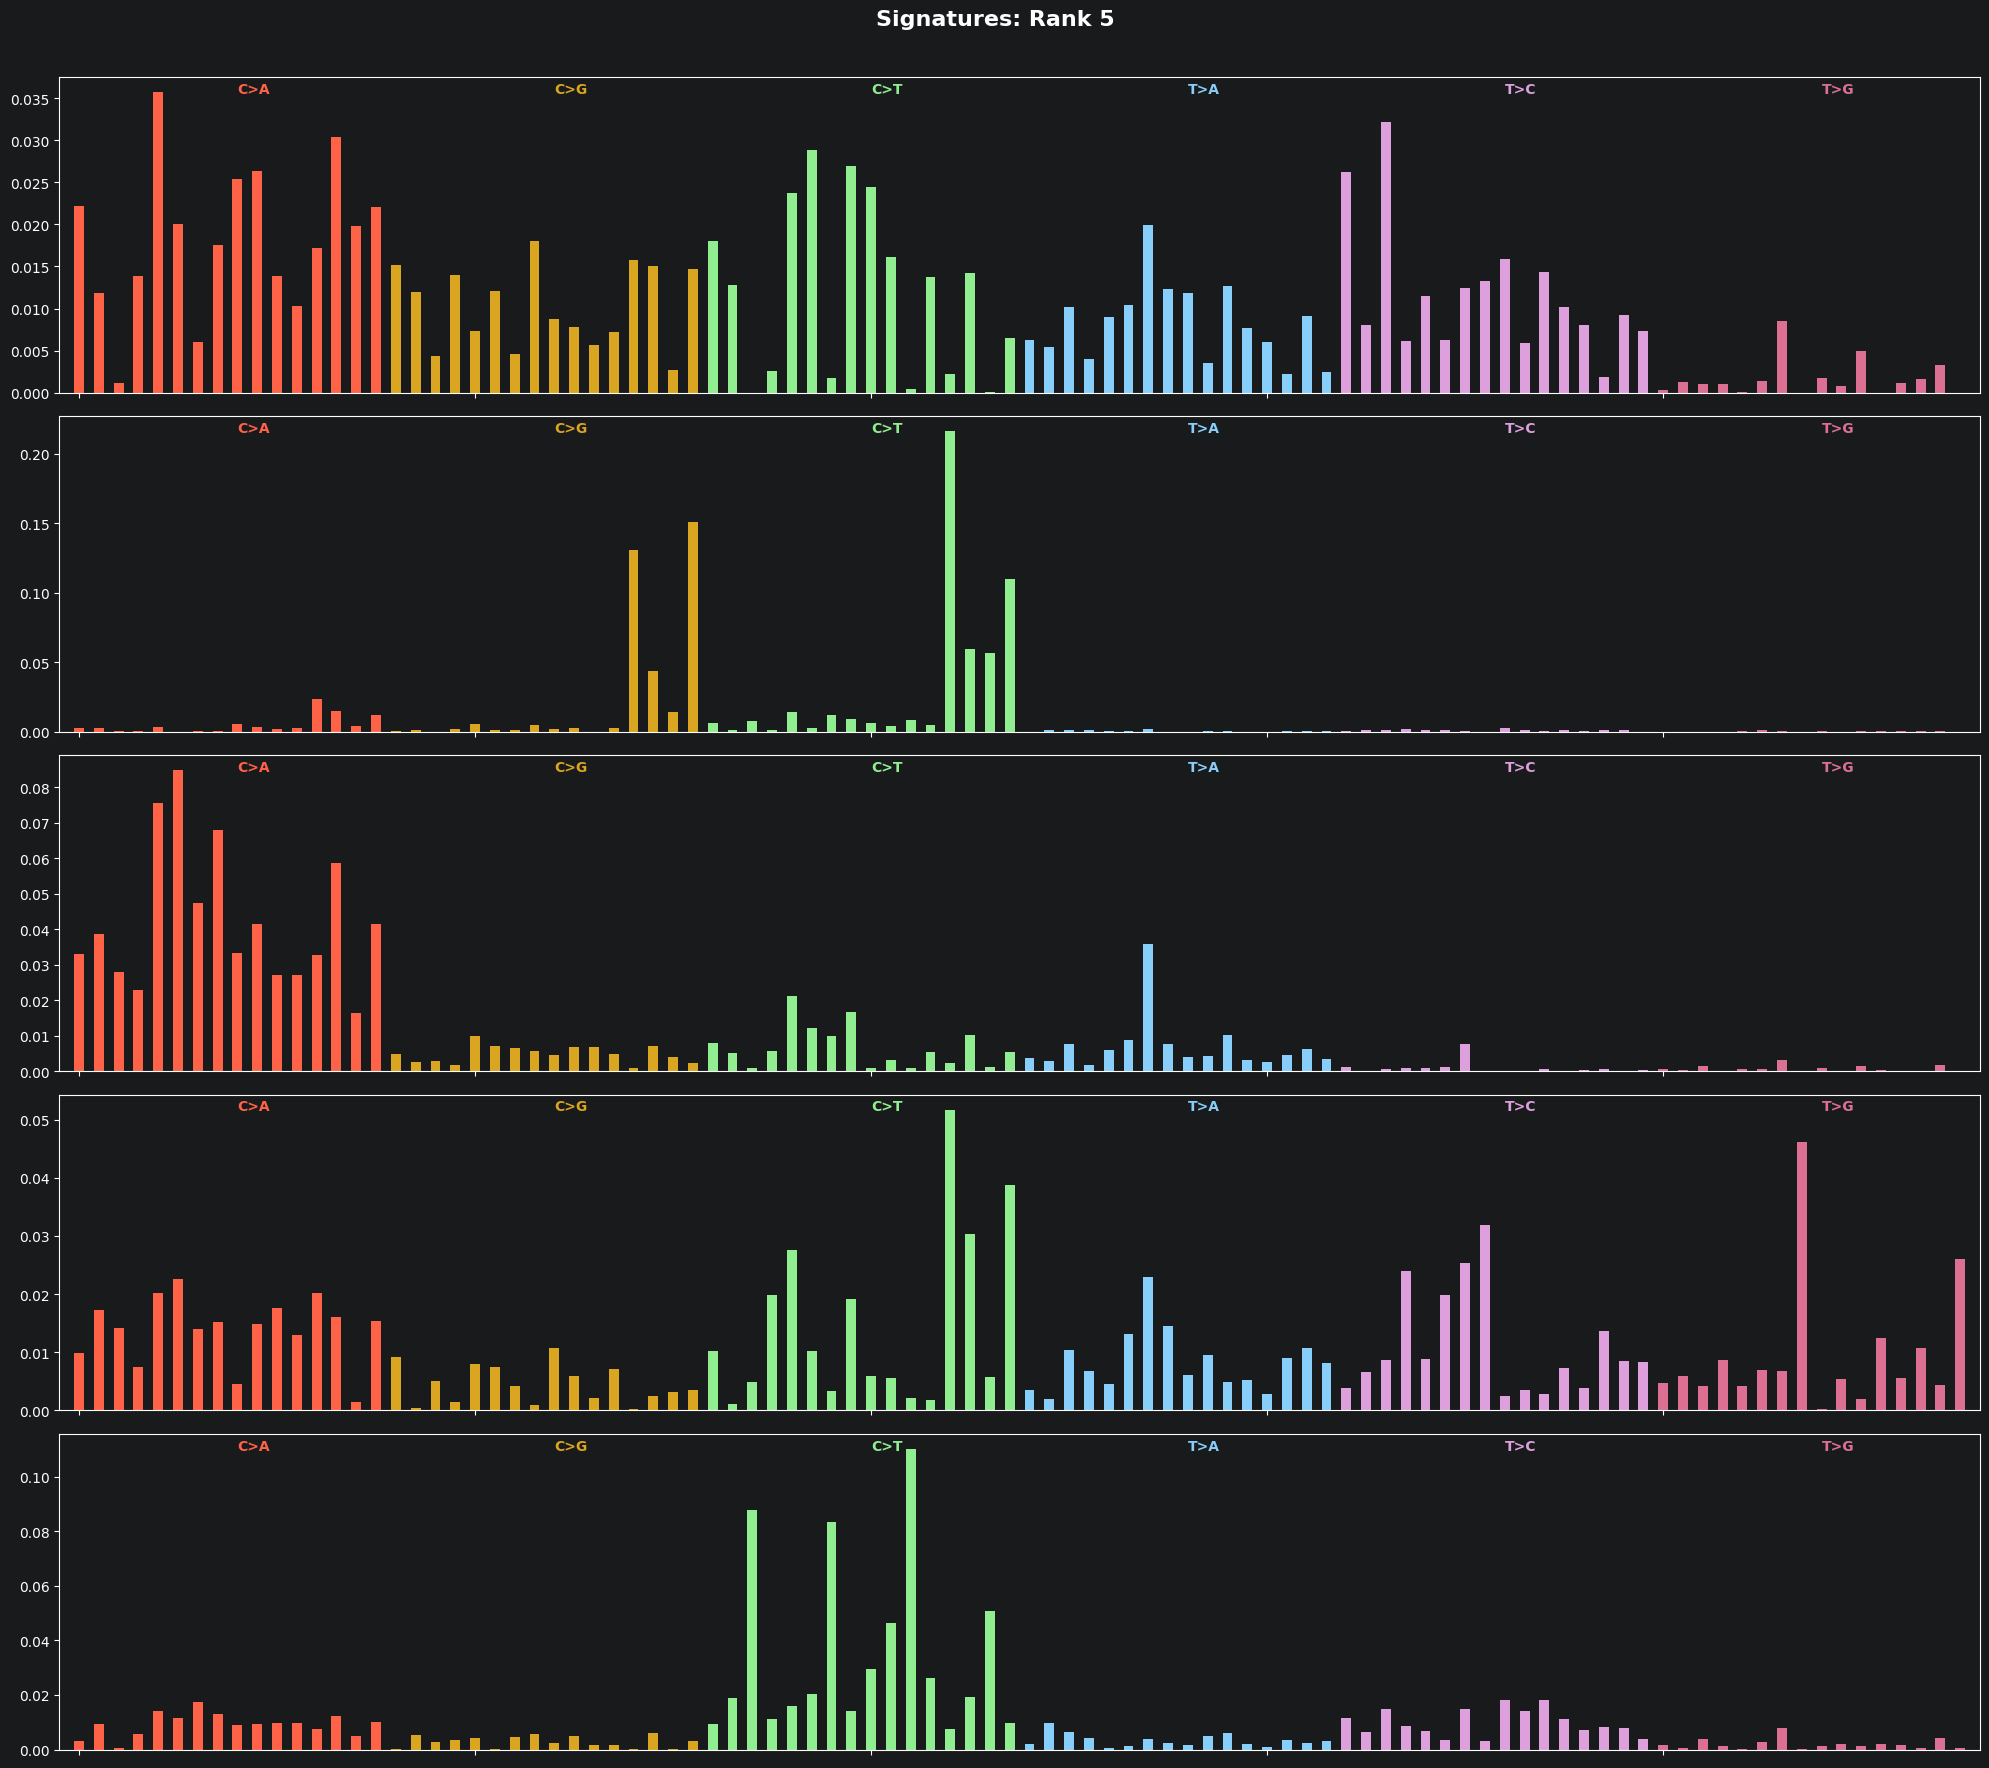

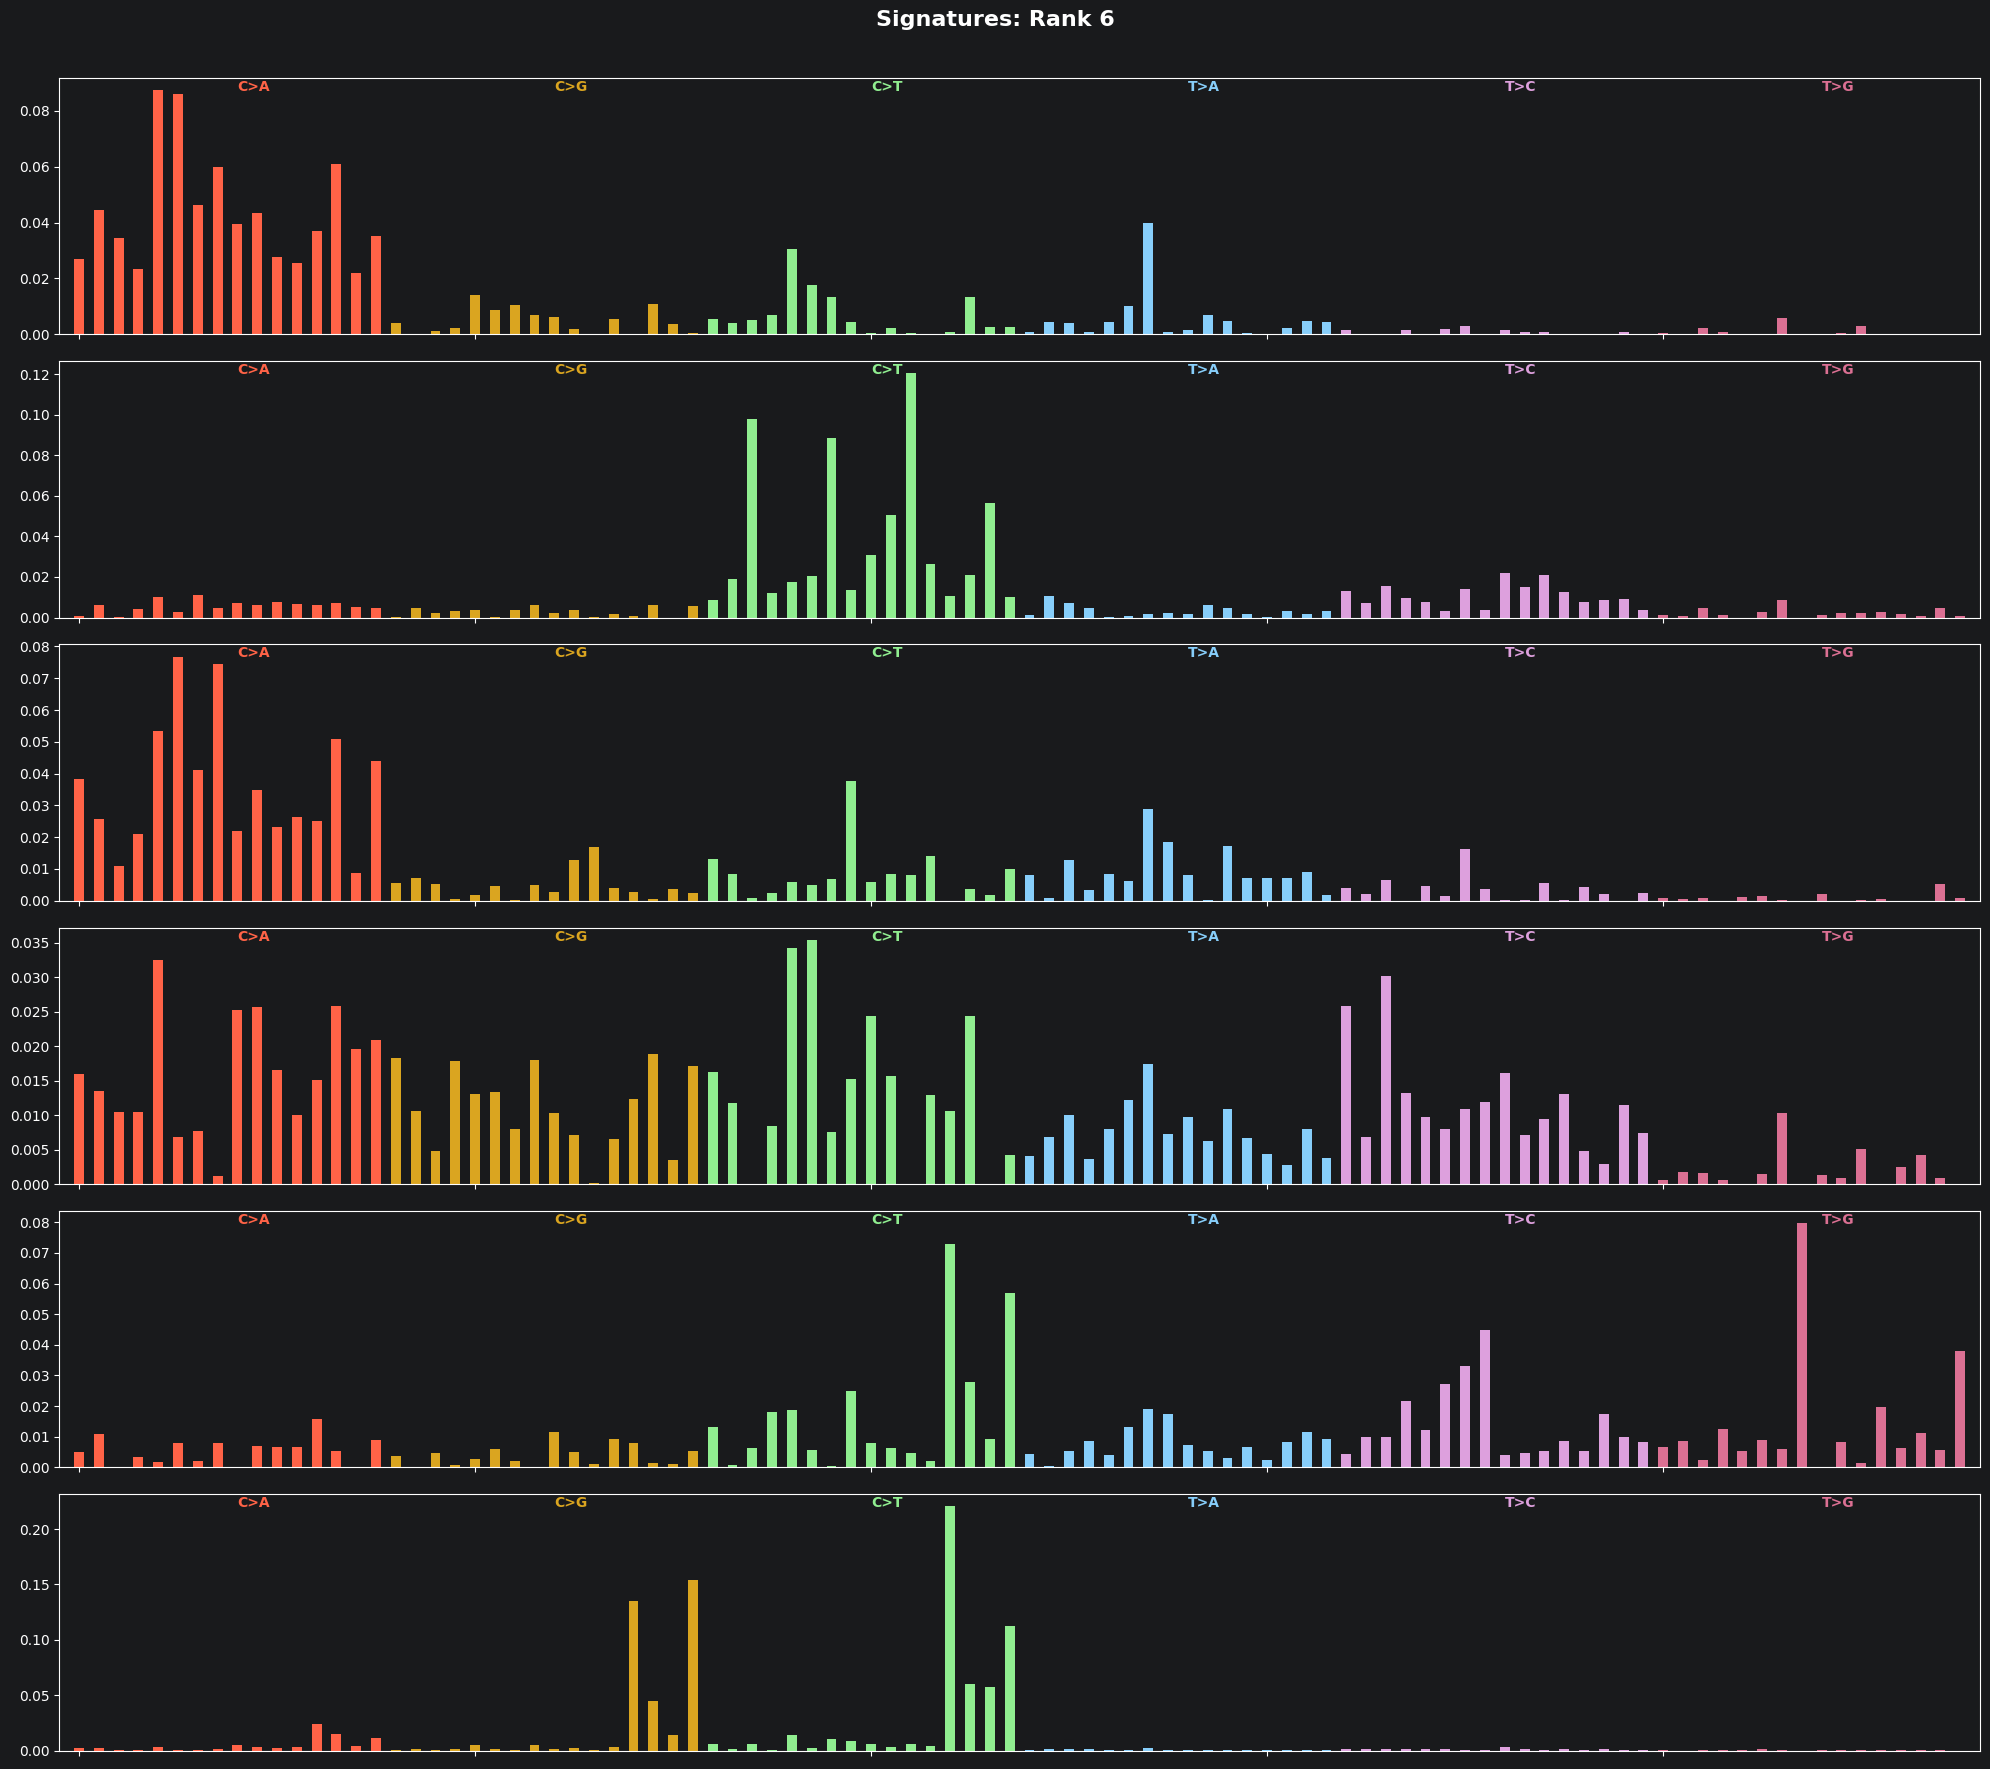

In [26]:
candidate_K = np.arange(2, 7)
for k in candidate_K:
    graph_signatures(V, k)

k = 2 and k = 3 show distinct, interpretable signatures. Beyond k = 3, the additional signatures resemble split or noisy versions of the same processes instead of new biology. We settle on k = 3.

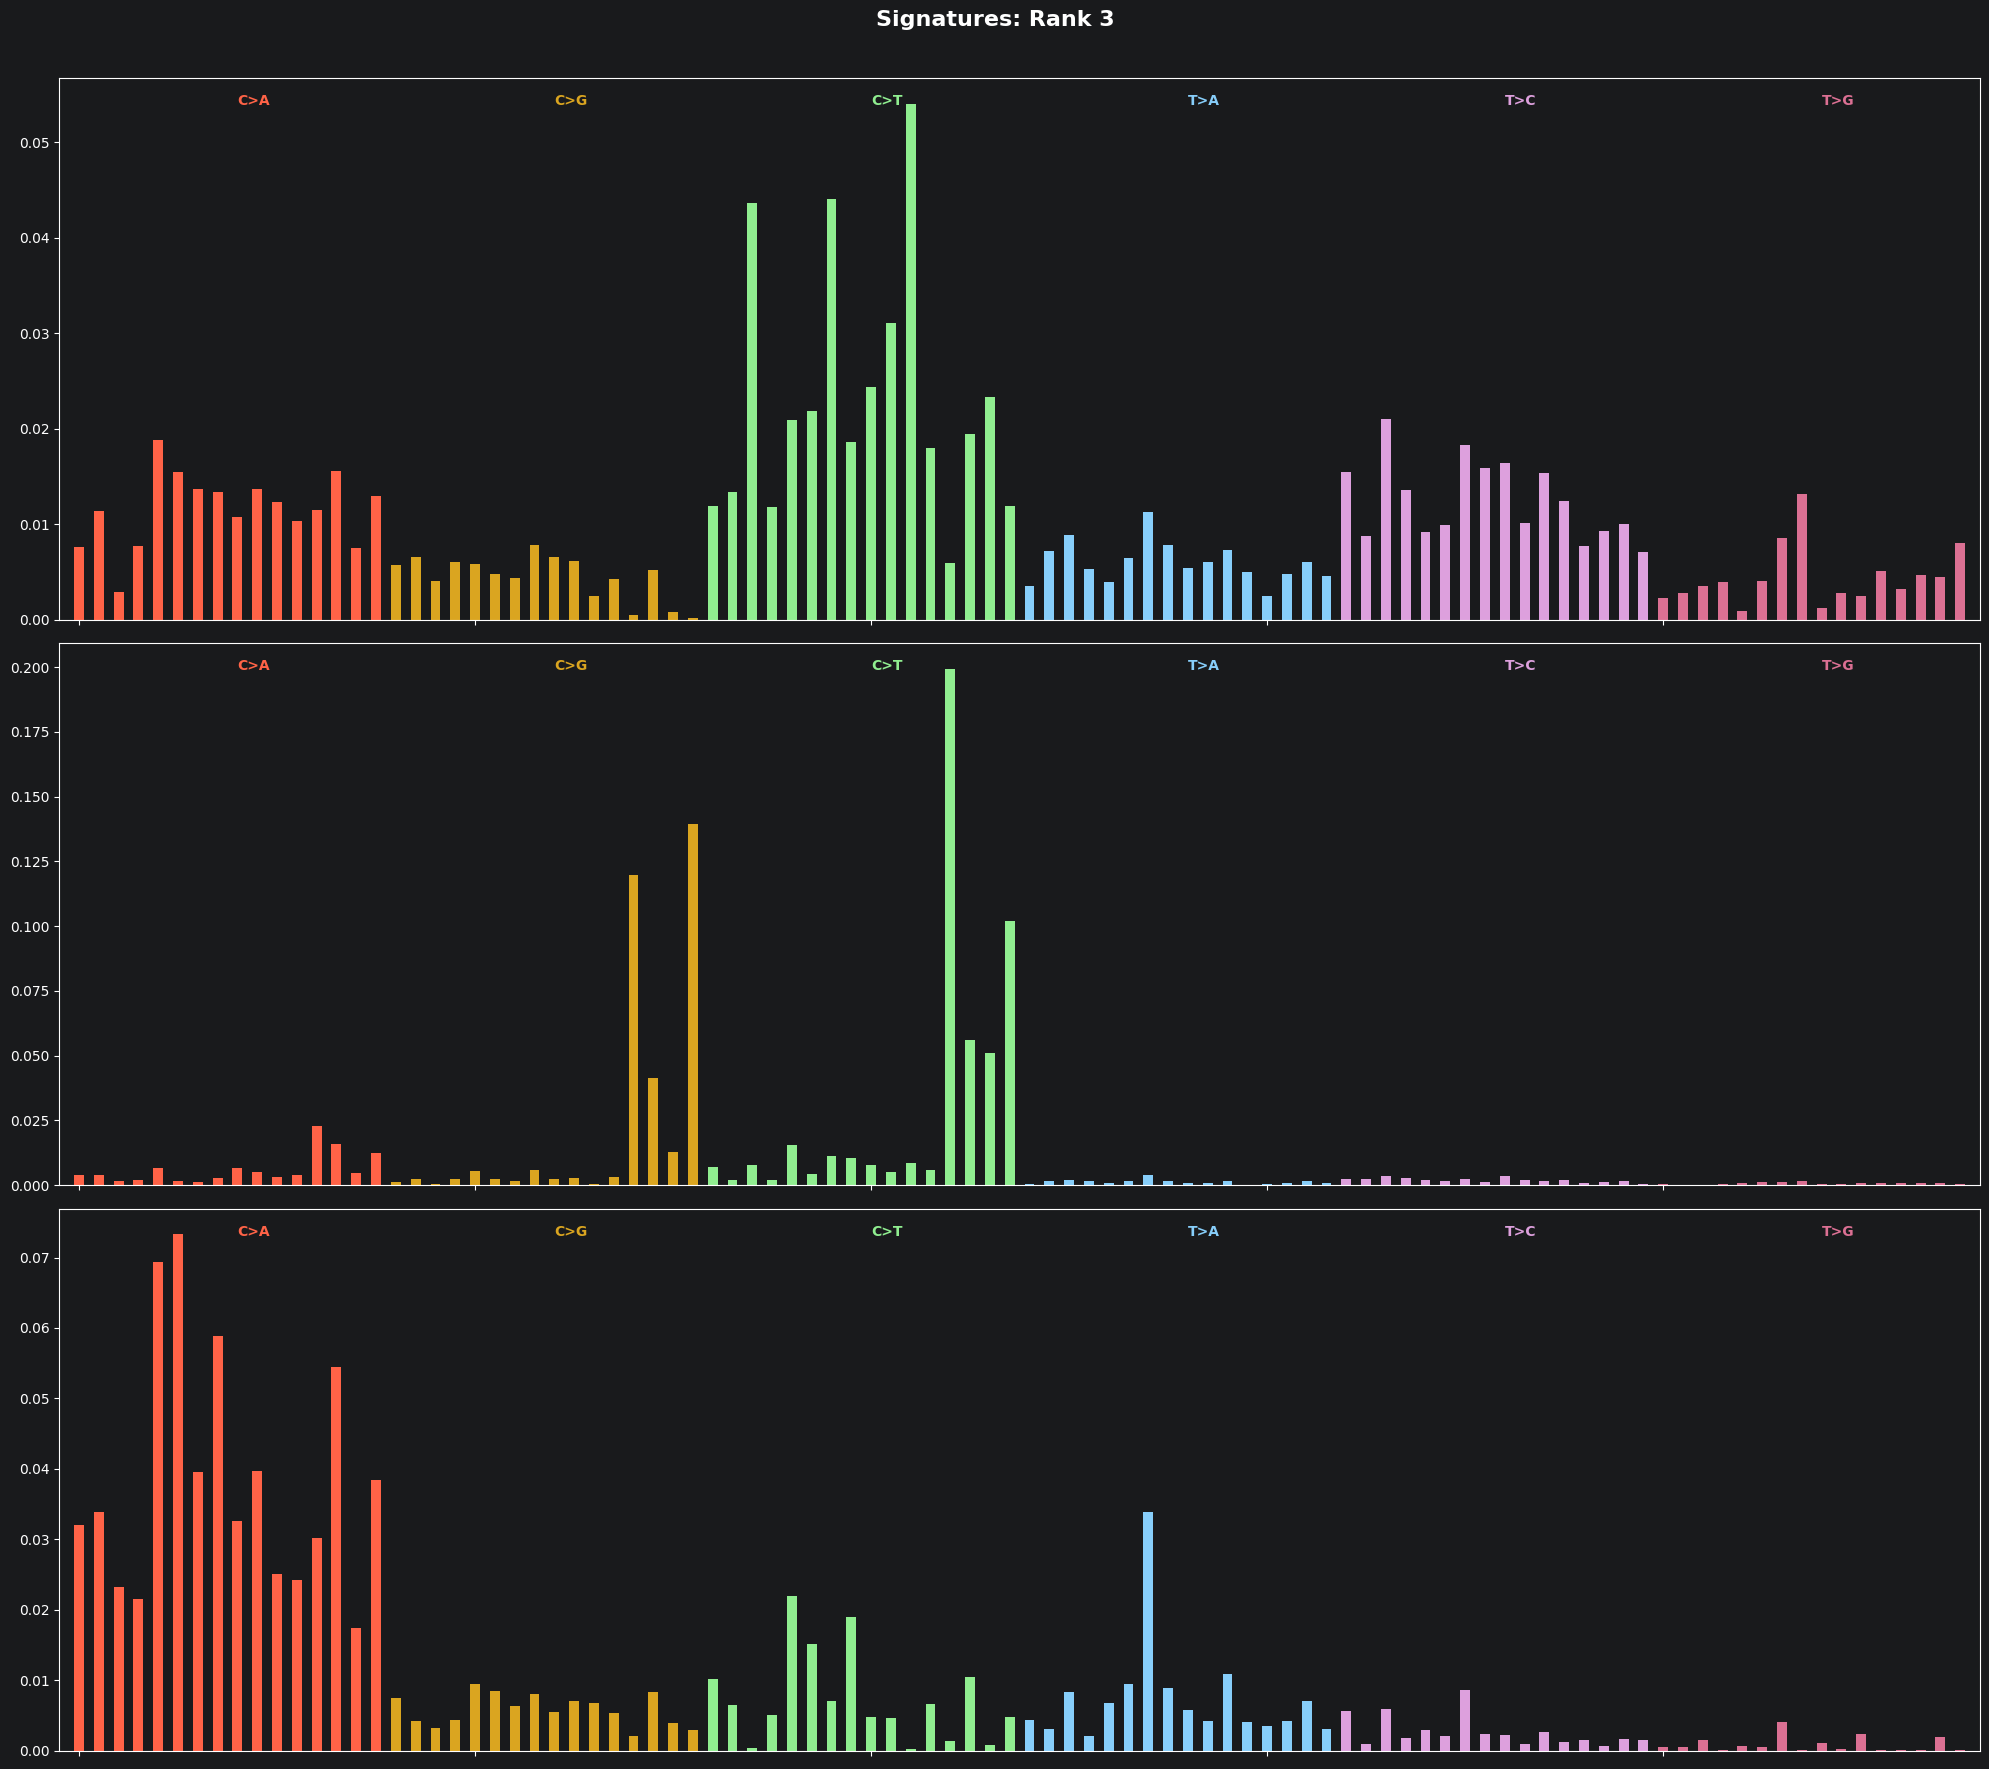

In [27]:
K = 3
graph_signatures(V, K)

We assemble the signatures at k = 3 into a DataFrame of the shape 96 x 3, where each row is a mutation type and each column is a signature.

In [28]:
W, H, min_error = find_min_error(V, K)

indices = []
for i in range(K):
    indices.append(f"Sig{i+1}")

In [29]:
signatures = pd.DataFrame(H, columns=channels, index=indices)
signatures = signatures.T
signatures = signatures / signatures.sum()

print(signatures.shape)
signatures.head()

(96, 3)


,Sig1,Sig2,Sig3
A[C>A]A,0.007579,0.003765,0.032085
A[C>A]C,0.011377,0.003888,0.033853
A[C>A]G,0.002866,0.001425,0.023233
A[C>A]T,0.007761,0.001846,0.021546
C[C>A]A,0.018786,0.006462,0.069294


### Step 4 - COSMIC Matching

We downloaded the COSMIC v3.4 SBS (hg38) reference and read into a pandas DataFrame. We then compute cosine similarity between each extracted signature and every COSMIC signature.

In [30]:
cosmic = pd.read_csv("data/raw/COSMIC_v3.6_SBS_GRCh38.txt", sep="\t", index_col=0)
cosmic = cosmic.reindex(channels)
print(cosmic.shape)
cosmic.head()

(96, 101)


,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,SBS7d,...,SBS104,SBS105,SBS106,SBS107,SBS108,SBS109,SBS110,SBS111,SBS112,SBS113
Type,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,0.000876,5.789892e-07,0.020920,0.042451,0.012052,0.000425,0.000067,0.002344,0.004841,0.000040,...,0.010658,0.002101,0.000376,0.005540,0.005254,0.018792,0.008594,0.011217,0.007012,0.095867
A[C>A]C,0.002220,1.455043e-04,0.016343,0.032990,0.009337,0.000516,0.000177,0.000457,0.001135,0.000754,...,0.009649,0.003659,0.000329,0.025288,0.001513,0.012304,0.012468,0.012825,0.026770,0.003305
A[C>A]G,0.000180,5.361706e-05,0.001808,0.016116,0.001908,0.000053,0.000073,0.000192,0.000388,0.000257,...,0.001615,0.000262,0.000030,0.001584,0.000418,0.001554,0.000911,0.001145,0.002094,0.000246
A[C>A]T,0.001265,9.758841e-05,0.012265,0.029663,0.006636,0.000180,0.000249,0.000714,0.001964,0.004051,...,0.011605,0.004275,0.000449,0.051158,0.002855,0.014507,0.006085,0.009626,0.009638,0.003447
C[C>A]A,0.000305,2.053143e-04,0.022376,0.080269,0.007379,0.001800,0.000451,0.001134,0.000108,0.014348,...,0.007980,0.016571,0.000670,0.017656,0.002078,0.019832,0.010944,0.022469,0.017275,0.474612


In [31]:
S = cosine_similarity(signatures.T.values, cosmic.T.values)
matches = pd.DataFrame(S, index=signatures.columns, columns=cosmic.columns)
for name in matches.index:
    top = matches.loc[name].sort_values(ascending=False).head(3)
    print(name, "->", ", ".join(f"{cosmic_value} ({similarity:.3f})" for cosmic_value, similarity in top.items()))

Sig1 -> SBS5 (0.768), SBS6 (0.763), SBS111 (0.746)
Sig2 -> SBS2 (0.762), SBS13 (0.635), SBS7a (0.616)
Sig3 -> SBS4 (0.979), SBS100 (0.915), SBS95 (0.861)


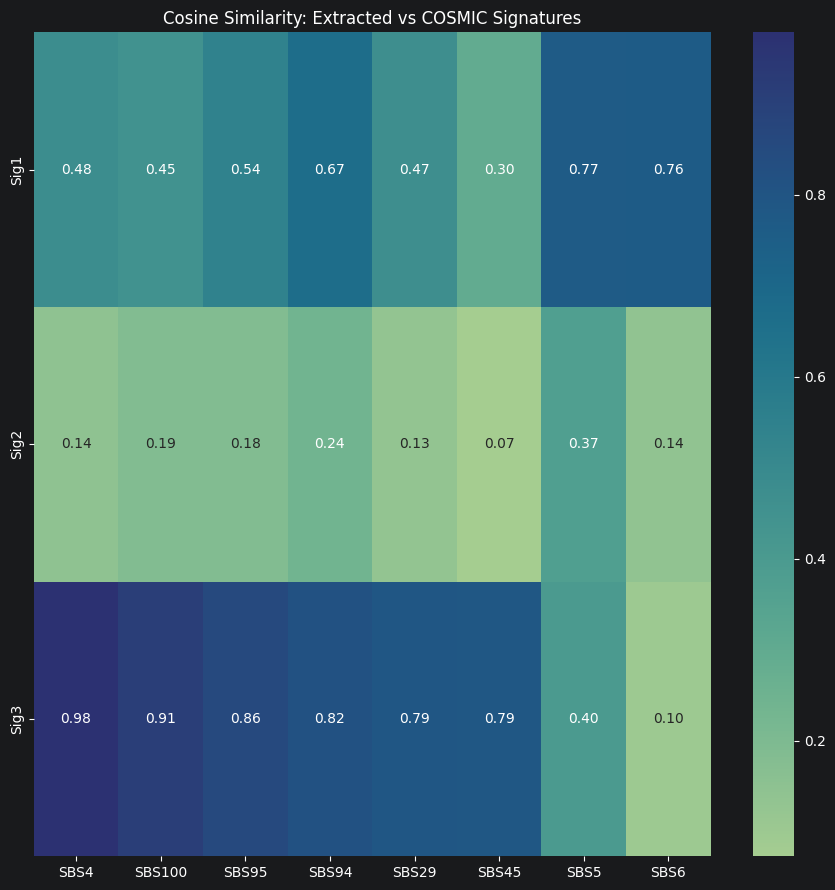

In [32]:
top_cols = matches.max().sort_values(ascending=False).head(8).index
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(matches[top_cols], ax=ax, annot=True, fmt=".2f", cmap="crest")
plt.title("Cosine Similarity: Extracted vs COSMIC Signatures")
plt.tight_layout()
plt.savefig("results/figures/cosmic_match.png", dpi=150)
plt.show()

For Signature 1, the best match is either SBS5 (clock-like in nature, i.e. increases with age) or SBS6 (associated with defective DNA repair). The former has a cosine similarity value of 0.768 while the latter has a value of 0.763.
For Signature 2, the best match is SBS2, with a cosine similarity of 0.762. SBS2 is often found with SBS13 (0.635), which happens to be the next best match. Together, these point to APOBEC, a family of proteins known to cause hypermutations in DNA.
For Signature 3, the best match by far is SBS4, with a cosine similarity of 0.979. SBS4 is associated with tobacco smoking.

In [33]:
rename_map = {
    "Sig1": "SBS5 / SBS6",
    "Sig2": "SBS2 / SBS13",
    "Sig3": "SBS4",
}
renamed_signatures = signatures.rename(columns=rename_map)
renamed_signatures.head()

,SBS5 / SBS6,SBS2 / SBS13,SBS4
A[C>A]A,0.007579,0.003765,0.032085
A[C>A]C,0.011377,0.003888,0.033853
A[C>A]G,0.002866,0.001425,0.023233
A[C>A]T,0.007761,0.001846,0.021546
C[C>A]A,0.018786,0.006462,0.069294


### Step 5 - Exposures

The W matrix gives each tumor's exposure — the fraction of its mutations that can be attributed to each signature. When we plot this as a stacked bar per tumor, it shows which processes are active where. To visualize the graph clearer, we sort the tumors by APOBEC exposure.

In [34]:
W_df = pd.DataFrame(W, index=matrix.columns, columns=renamed_signatures.columns)
W_df = W_df.div(W_df.sum(axis=1), axis=0)
apobec = "SBS2 / SBS13"
W_df = W_df.sort_values(apobec, ascending=False)

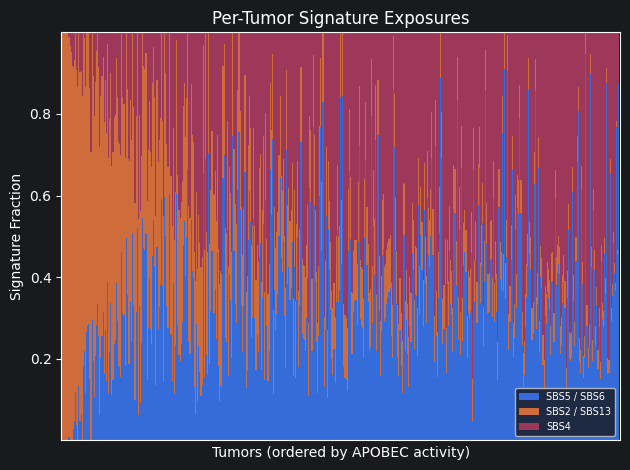

In [35]:
fig, ax = plt.subplots()
bottom = np.zeros(len(W_df))

for name in W_df.columns:
    ax.bar(range(len(W_df)), W_df[name].values, bottom=bottom, width=1.0, label=name)
    bottom += W_df[name].values

ax.set_xlim(0, len(W_df))
ax.set_xlabel("Tumors (ordered by APOBEC activity)")
ax.set_ylabel("Signature Fraction")
ax.legend(ncol=1, fontsize="x-small")
ax.set_xticks([])

plt.title("Per-Tumor Signature Exposures")
plt.tight_layout()

plt.savefig("results/figures/per_tumor_signature_exposures.png", dpi=150)
plt.show()

From the graph, we can see that the signatures attributed to smoking and SBS5/SBS6 were broadly distributed across tumors, whereas APOBEC (SBS2 / SBS13) was episodic. It contributed to the majority, if not all, of the mutations in a small subset of tumors, but little to nothing in most.

### Step 6: Validation

To validate our pipeline, we run SigProfilerExtractor — an established, heavily-optimized tool for de novo signature extraction — on the same catalogue. We read the results from the SigProfilerExtractor and compare our signatures to the results by cosine similarity.

In [36]:
df = pd.read_csv("data/processed/sbs96_matrix.csv")

df.to_csv(
    "data/processed/sbs96_matrix.txt",
    sep="\t",
    index=False
)

In [37]:
from SigProfilerExtractor import sigpro as sig
if (not os.path.exists("results/sigprofiler")):
    sig.sigProfilerExtractor(input_type="matrix", output="results/sigprofiler", input_data="data/processed/sbs96_matrix.txt", context_type="96", minimum_signatures=2, maximum_signatures=6, nmf_replicates=25)

In [38]:
sig_results = pd.read_csv("results/sigprofiler/SBS96/Suggested_Solution/SBS96_De-Novo_Solution/Signatures/SBS96_De-Novo_Signatures.txt", sep="\t")
sig_results = sig_results.set_index("MutationType").reindex(channels)
print(sig_results.shape)
sig_results.head()

(96, 3)


,SBS96A,SBS96B,SBS96C
MutationType,,,
A[C>A]A,0.030228,5.091280e-03,0.002211
A[C>A]C,0.032571,6.928340e-03,0.002515
A[C>A]G,0.021794,5.000000e-07,0.000639
A[C>A]T,0.021448,6.763200e-04,0.001652
C[C>A]A,0.067904,1.604990e-03,0.004304


In [39]:
S = cosine_similarity(signatures.T.values, sig_results.T.values)

sig_matches = pd.DataFrame(S, index=signatures.columns, columns=sig_results.columns)
print(sig_matches.shape)
sig_matches.head()

(3, 3)


,SBS96A,SBS96B,SBS96C
Sig1,0.532799,0.946483,0.200369
Sig2,0.131684,0.235814,0.999408
Sig3,0.999407,0.233952,0.116847


In [40]:
for name in matches.index:
    top = sig_matches.loc[name].sort_values(ascending=False).head(3)
    print(name, "->", ", ".join(f"{c} ({v:.3f})" for c, v in top.items()))

Sig1 -> SBS96B (0.946), SBS96A (0.533), SBS96C (0.200)
Sig2 -> SBS96C (0.999), SBS96B (0.236), SBS96A (0.132)
Sig3 -> SBS96A (0.999), SBS96B (0.234), SBS96C (0.117)


Signature 1 matches SBS96B with a similarity of 0.946, Signature 2 matches SBS96C with a similarity of 0.999, and Signature 3 matches SBS96A with a similarity of 0.999. It seems that our hand-built NMF recovered essentially the same signatures as the field-standard tool. Is the identity of the signatures the same? To answer that question, we examine SigProfiler's own COSMIC decomposition.

In [41]:
sig_cosmic = pd.read_csv("results/sigprofiler/SBS96/Suggested_Solution/COSMIC_SBS96_Decomposed_Solution/Signatures/COSMIC_SBS96_Signatures.txt", sep="\t")
sig_cosmic = sig_cosmic.set_index("MutationType").reindex(channels)
print(sig_cosmic.shape)
sig_cosmic.head()

(96, 6)


,SBS1,SBS2,SBS4,SBS5,SBS6,SBS13
MutationType,,,,,,
A[C>A]A,0.000886,5.800000e-07,0.042196,0.011998,0.000425,0.001820
A[C>A]C,0.002280,1.480000e-04,0.033297,0.009438,0.000524,0.000721
A[C>A]G,0.000177,5.230000e-05,0.015599,0.001850,0.000052,0.000264
A[C>A]T,0.001280,9.780000e-05,0.029498,0.006609,0.000180,0.000348
C[C>A]A,0.000312,2.080100e-04,0.080693,0.007429,0.001821,0.001400


In [42]:
S = cosine_similarity(signatures.T.values, sig_cosmic.T.values)
sig_cosmic_matches = pd.DataFrame(S, index=signatures.columns, columns=sig_cosmic.columns)
print(sig_cosmic_matches.shape)
sig_cosmic_matches.head()

(3, 6)


,SBS1,SBS2,SBS4,SBS5,SBS6,SBS13
Sig1,0.618268,0.119723,0.478211,0.766802,0.762762,0.051968
Sig2,0.090494,0.761867,0.144028,0.369865,0.137144,0.635444
Sig3,0.031520,0.031600,0.978514,0.399201,0.102212,0.096700


In [43]:
for name in sig_cosmic_matches.index:
    top = sig_cosmic_matches.loc[name].sort_values(ascending=False).head(3)
    print(name, "->", ", ".join(f"{c} ({v:.3f})" for c, v in top.items()))

Sig1 -> SBS5 (0.767), SBS6 (0.763), SBS1 (0.618)
Sig2 -> SBS2 (0.762), SBS13 (0.635), SBS5 (0.370)
Sig3 -> SBS4 (0.979), SBS5 (0.399), SBS6 (0.102)


In conclusion, SigProfilerExtractor, run independently on the same catalogue, recovered three signatures whose COSMIC matches agree with those from our NMF: SBS5 (0.767, with SBS6 next at 0.618) for Signature 1, SBS2 (0.762) followed by SBS13 (0.635) for Signature 2, and SBS4 (0.979) for Signature 3. The fact that an established, more heavily optimized tool converges on the same three processes — smoking (SBS4), APOBEC (SBS2/13), and an SBS5/6-like background — reinforces the validity of our extracted signatures.